In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import streamlit as st

plt.style.use("ggplot")

In [25]:
df=pd.read_csv("D:\Cognetix_Internship\Cognetix_Covid_Analysis\data\Covid19_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Pranjal Rai\AppData\Local\Temp\ipykernel_9360\1554355059.py:1: SyntaxWarning: invalid escape sequence '\C'
  df=pd.read_csv("D:\Cognetix_Internship\Cognetix_Covid_Analysis\data\Covid19_data.csv")


In [26]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,1/22/2020,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,1/22/2020,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,1/22/2020,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,1/22/2020,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,1/22/2020,0,0,0,0,Africa


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [28]:
df.shape

(49068, 10)

In [29]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [30]:
#Convert Date column to datetime format
df["Date"]=pd.to_datetime(df["Date"])

In [31]:
df.dtypes

Province/State            object
Country/Region            object
Lat                      float64
Long                     float64
Date              datetime64[ns]
Confirmed                  int64
Deaths                     int64
Recovered                  int64
Active                     int64
WHO Region                object
dtype: object

In [32]:
#Checking for missing values
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [33]:
#Filling missing values in Province/State column with "Unknown"
df["Province/State"]=df["Province/State"].fillna("Unknown")

In [34]:
df.fillna(0, inplace=True)

In [35]:
#Standardize Country Names
df["Country/Region"]=df["Country/Region"].str.strip()

In [36]:
df["Country/Region"]=df["Country/Region"].replace({
    "US":"USA",
    "Mainland China":"China"
})

In [37]:
#Checking for Duplicates
df.duplicated().sum()

np.int64(0)

In [38]:
#Removing Duplicates
df.drop_duplicates(inplace=True)

In [39]:
df.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


In [40]:
#NNumber of Countries
df["Country/Region"].nunique()

187

In [41]:
#Total Records
len(df)

49068

In [42]:
india=df[df["Country/Region"]=="India"]

In [43]:
india.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,Unknown,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,Unknown,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,Unknown,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,Unknown,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,Unknown,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia


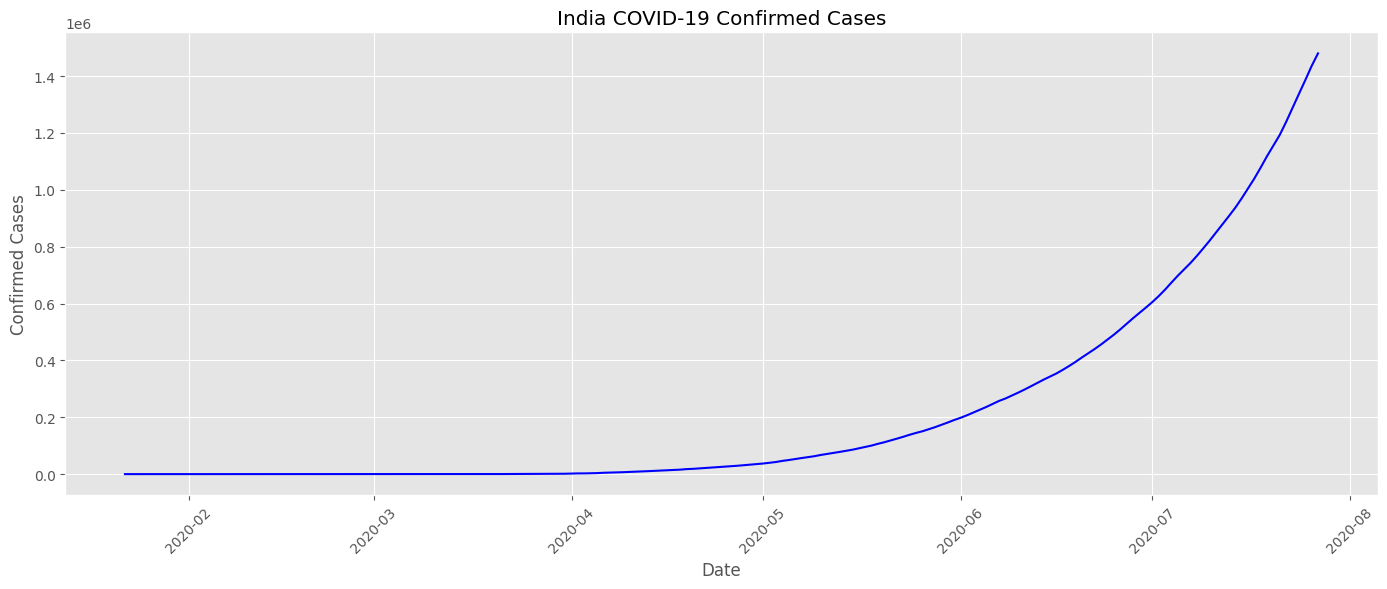

In [44]:
#Plot Daily Confirmed Cases in India
plt.figure(figsize=(14,6))
plt.plot(india["Date"],
         india["Confirmed"],
         color="blue")
plt.title("India COVID-19 Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

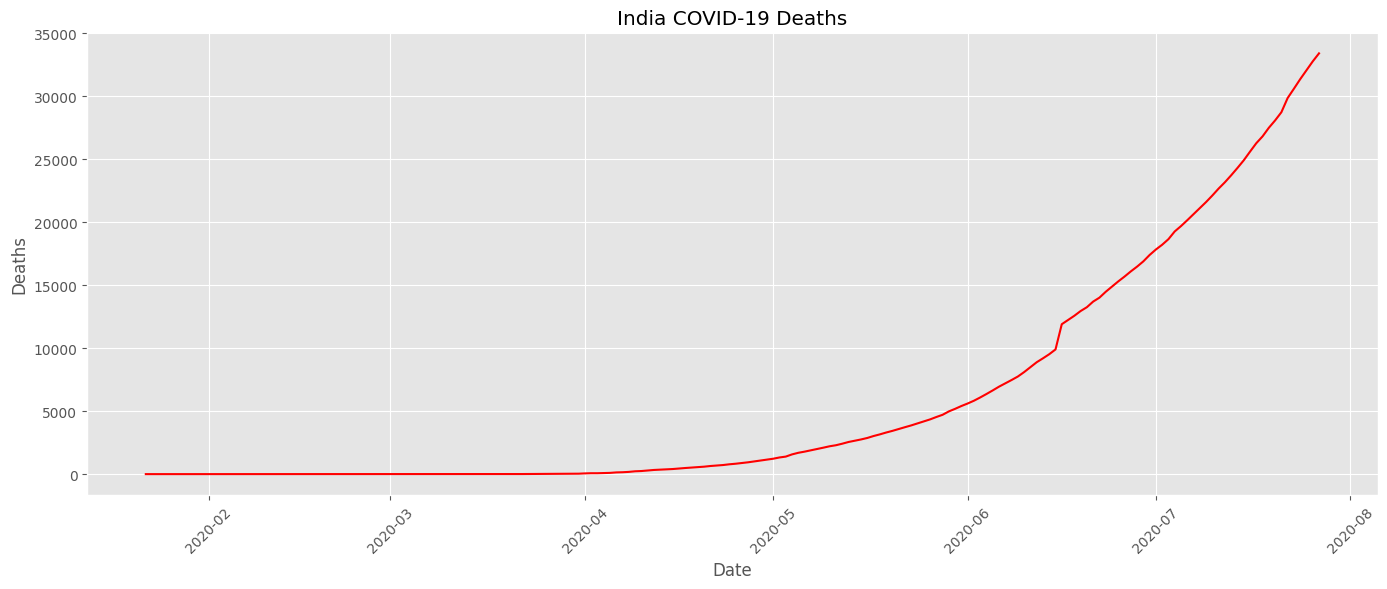

In [45]:
#Plot Daily Deaths in India
plt.figure(figsize=(14,6))
plt.plot(india["Date"],
         india["Deaths"],
         color="red")
plt.title("India COVID-19 Deaths")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

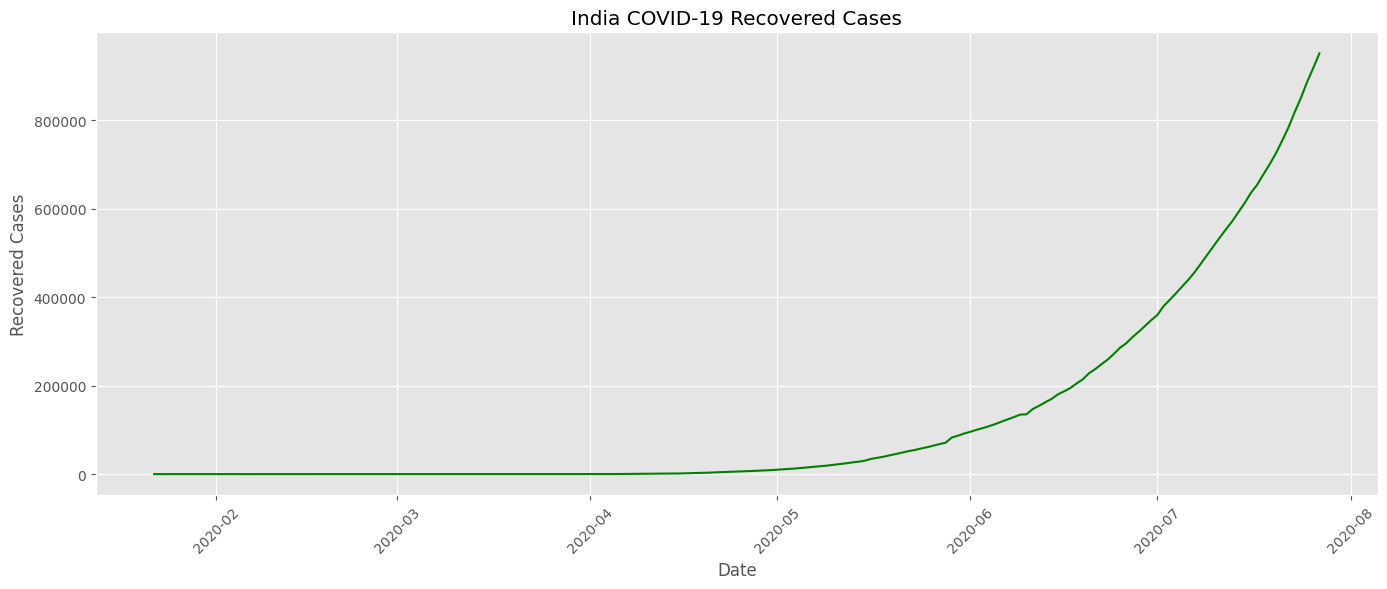

In [46]:
#Plot Recovered Cases in India
plt.figure(figsize=(14,6))
plt.plot(india["Date"], india["Recovered"], color="green")
plt.title("India COVID-19 Recovered Cases")
plt.xlabel("Date")
plt.ylabel("Recovered Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
#Active Cases in India
df["Active"]=df["Confirmed"]-df["Deaths"]-df["Recovered"]

In [48]:
india=df[df["Country/Region"]=="India"]

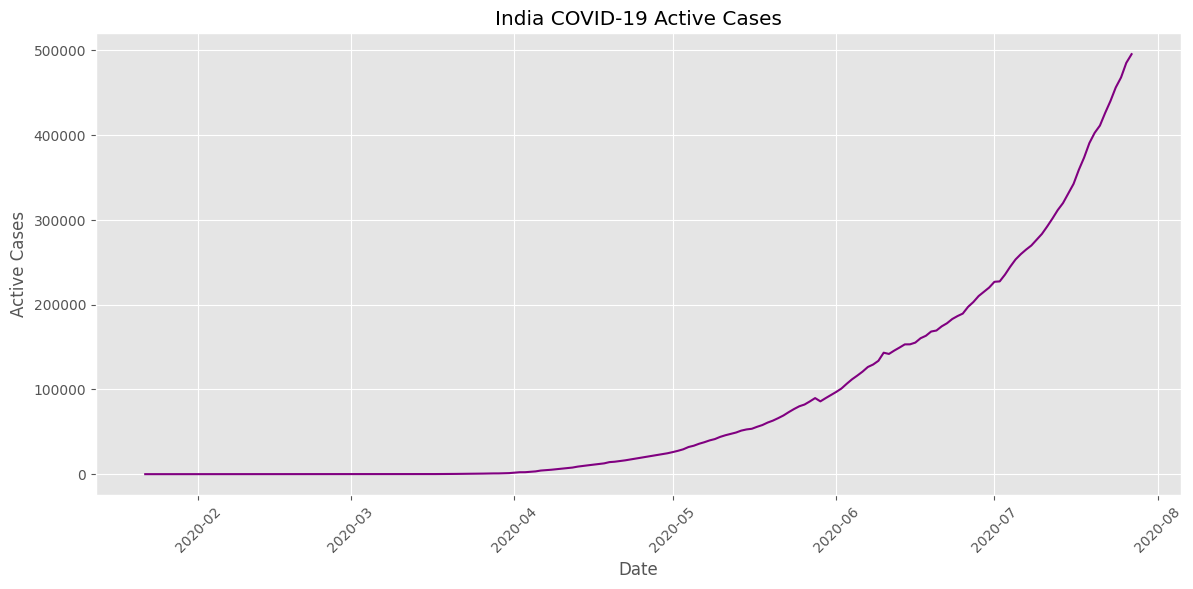

In [49]:
plt.figure(figsize=(14,6))
plt.plot(india["Date"], india["Active"], color="purple")
plt.title("India COVID-19 Active Cases")
plt.xlabel("Date")
plt.ylabel("Active Cases")
plt.xticks(rotation=45)
plt.show()

In [50]:
#Add Rolling Average
india["Rolling_Confirmed"]=india["Confirmed"].rolling(7).mean()

C:\Users\Pranjal Rai\AppData\Local\Temp\ipykernel_9360\1541343344.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india["Rolling_Confirmed"]=india["Confirmed"].rolling(7).mean()


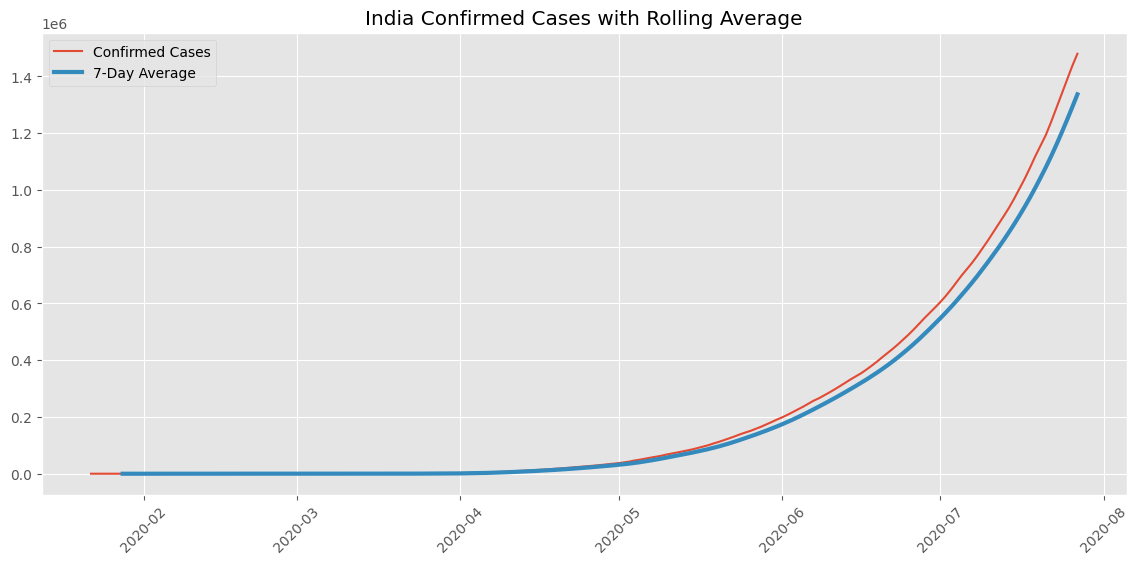

In [51]:
plt.figure(figsize=(14,6))
plt.plot(india["Date"], india["Confirmed"], label="Confirmed Cases")
plt.plot(india["Date"],india["Rolling_Confirmed"],linewidth=3,label="7-Day Average")
plt.legend()
plt.xticks(rotation=45)
plt.title("India Confirmed Cases with Rolling Average")
plt.show()



In [52]:
#Country Comparison
countries=["India","USA","China"]
comparison=df[df["Country/Region"].isin(countries)]


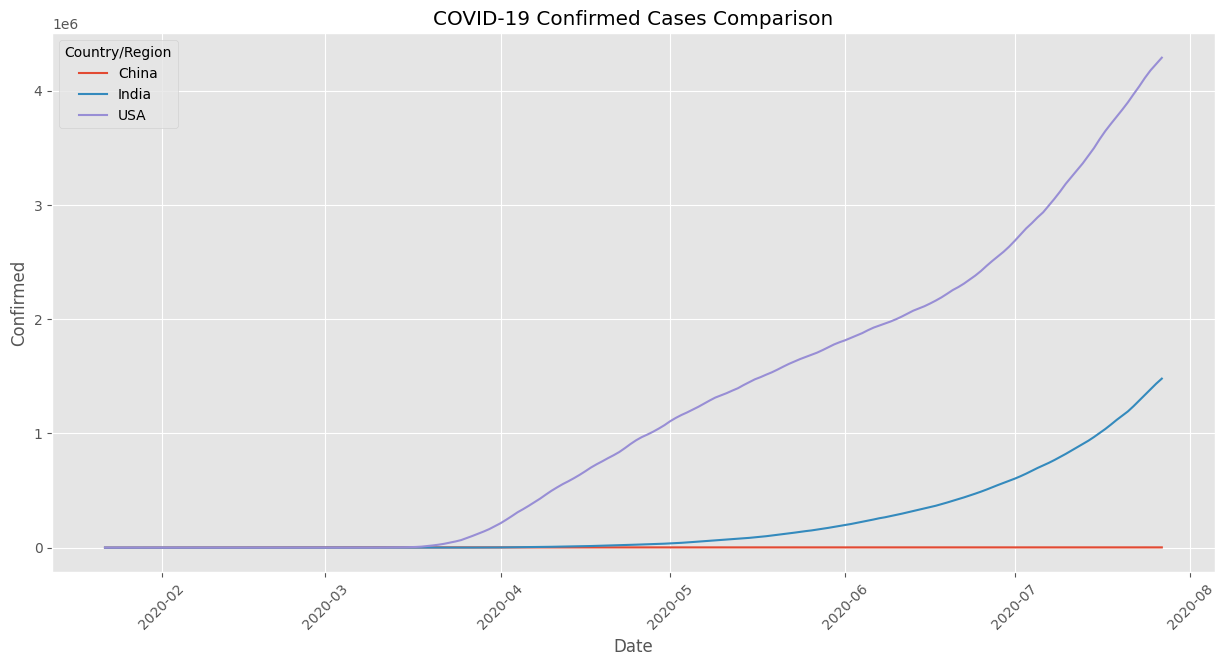

In [53]:
plt.figure(figsize=(15,7))
sns.lineplot(data=comparison, x="Date", y="Confirmed", hue="Country/Region")
plt.title("COVID-19 Confirmed Cases Comparison")
plt.xticks(rotation=45)
plt.show()

In [54]:
#Top 10 Countries
latest=df[df["Date"]==df["Date"].max()]


In [55]:
top10=latest.groupby("Country/Region")["Confirmed"].sum().sort_values(ascending=False).head(10)

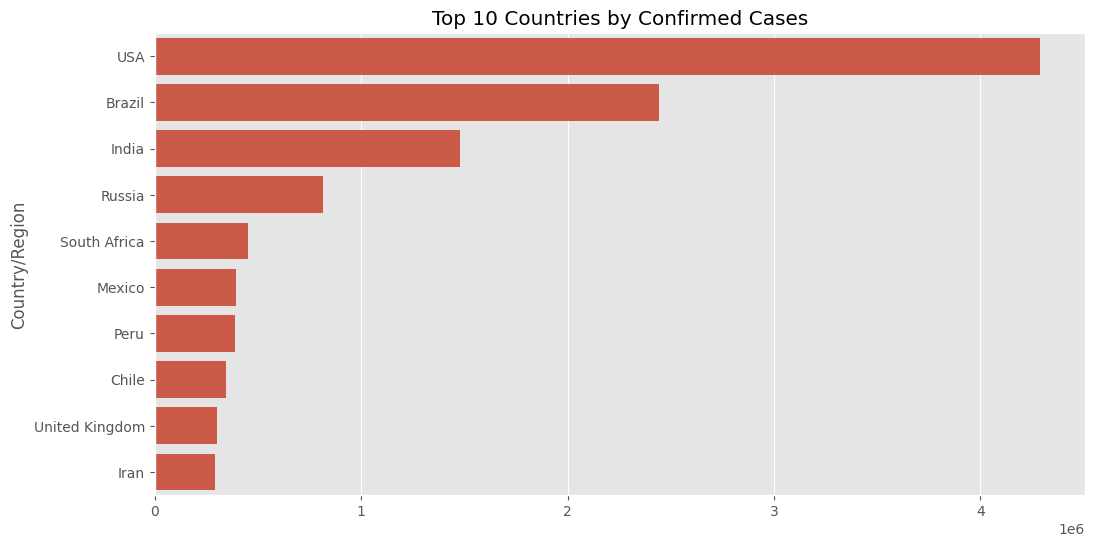

In [56]:
plt.figure(figsize=(12,6))
sns.barplot(x=top10.values,y=top10.index)
plt.title("Top 10 Countries by Confirmed Cases")
plt.show()

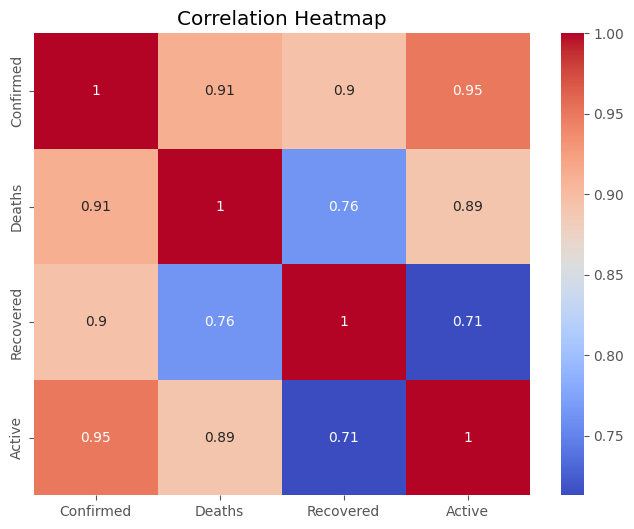

In [57]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[["Confirmed","Deaths","Recovered","Active"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [58]:
#Monthly Trend
df["Month"]=df["Date"].dt.to_period("M")

In [59]:
india=df[df["Country/Region"]=="India"]

In [60]:
monthly=india.groupby("Month")["Confirmed"].sum()

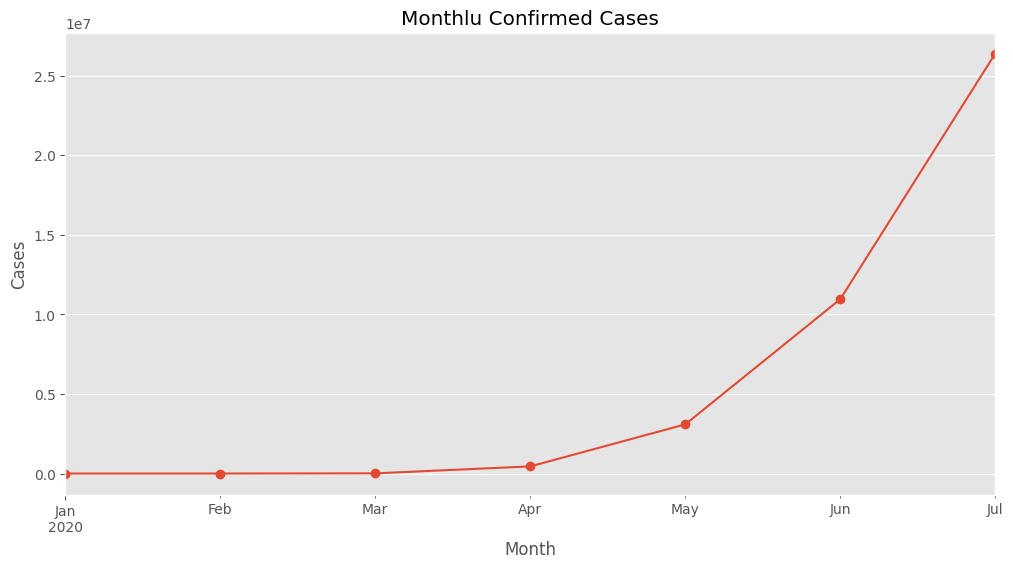

In [61]:
monthly.plot(figsize=(12,6),marker="o")
plt.title("Monthlu Confirmed Cases")
plt.ylabel("Cases")
plt.show()

In [62]:
#Pie Chart
latest=df[df["Date"]==df["Date"].max()]

In [63]:
#Top Five
top5=latest.groupby("Country/Region")["Confirmed"].sum().sort_values(ascending=False).head(5)

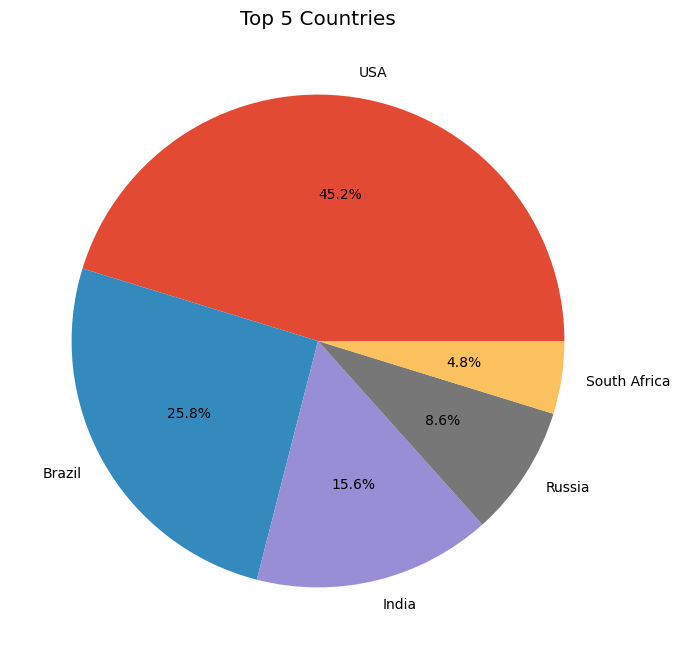

In [64]:
plt.figure(figsize=(8,8))
plt.pie(top5,labels=top5.index,autopct="%1.1f%%")
plt.title("Top 5 Countries")
plt.show()

In [65]:
df.to_csv("Covid_19_Data.csv",index=False)

In [66]:
df["Month"] = df["Date"].dt.strftime("%Y-%m")

In [67]:
st.write(df.dtypes)

2026-07-17 23:48:18.267 Serialization of dataframe to Arrow table was unsuccessful. Applying automatic fixes for column types to make the dataframe Arrow-compatible.
Traceback (most recent call last):
  File "d:\Python 3.12.4\Lib\site-packages\streamlit\dataframe_util.py", line 961, in convert_pandas_df_to_arrow_bytes
    table = pa.Table.from_pandas(df)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "pyarrow\\table.pxi", line 4795, in pyarrow.lib.Table.from_pandas
  File "d:\Python 3.12.4\Lib\site-packages\pyarrow\pandas_compat.py", line 637, in dataframe_to_arrays
    arrays = [convert_column(c, f)
              ^^^^^^^^^^^^^^^^^^^^
  File "d:\Python 3.12.4\Lib\site-packages\pyarrow\pandas_compat.py", line 625, in convert_column
    raise e
  File "d:\Python 3.12.4\Lib\site-packages\pyarrow\pandas_compat.py", line 619, in convert_column
    result = pa.array(col, type=type_, from_pandas=True, safe=safe)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "pyarrow\

In [70]:
print(df["Country/Region"].unique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Brazil'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Congo (Brazzaville)' 'Congo (Kinshasa)' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Greenland' 'Djibouti'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guyana' 'Haiti' 'Holy See' 'Honduras' 'Hungary' 'Iceland'
 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica'
 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'South Korea' 'Kuwait' 'Kyrgyzstan'
 'Latvia' 'Lebanon' 'Liberia' 